# This Notebook creates a figure for paper. The figure shows examples of the simplified Yordanov ansatz without ladders.

In [19]:
#Qiskit modules
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
#from qiskit_ibm_runtime import EstimatorV2 as Estimator, QiskitRuntimeService
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.noise import NoiseModel, depolarizing_error

#math modules
import math
import numpy as np
import random

#Showing results
import matplotlib.pyplot as plt

# SciPy minimizer routine
from scipy.optimize import minimize

import time
import sys
sys.path.insert(0, 'C:/Users/Oleg/Google Диск/QC/Codes/QC-qiskit-codes/Library')

#My libraries
import vqe_funcs
import aux_func as af

from vqe_funcs import sigma_x, sigma_y, sigma_z, kinetic_energy, full_ham, particles_number_control, ry_c

In [20]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations. Initial state is FM state 
def anzatz_4(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    #initial state preparation
    for i in range(electrons_number):
        v_qc.x(i)
    #Variable block
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta, v_qc, 0)
    return v_qc

In [21]:
nodes_number = 4
electrons_number = 1
n_qubits = nodes_number * 2
len_se = n_qubits * (n_qubits - 1) / 2
len_de = n_qubits * (n_qubits - 1) * (n_qubits - 2) * (n_qubits - 3) / 4 / 2
len_tot = int(len_se + len_de)
len_tot = (3 * 2 * nodes_number * 2)
theta = [0]
for i in range(len_tot):
    theta.append(0)


init_guess = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

qc = anzatz_4(theta, nodes_number, electrons_number)

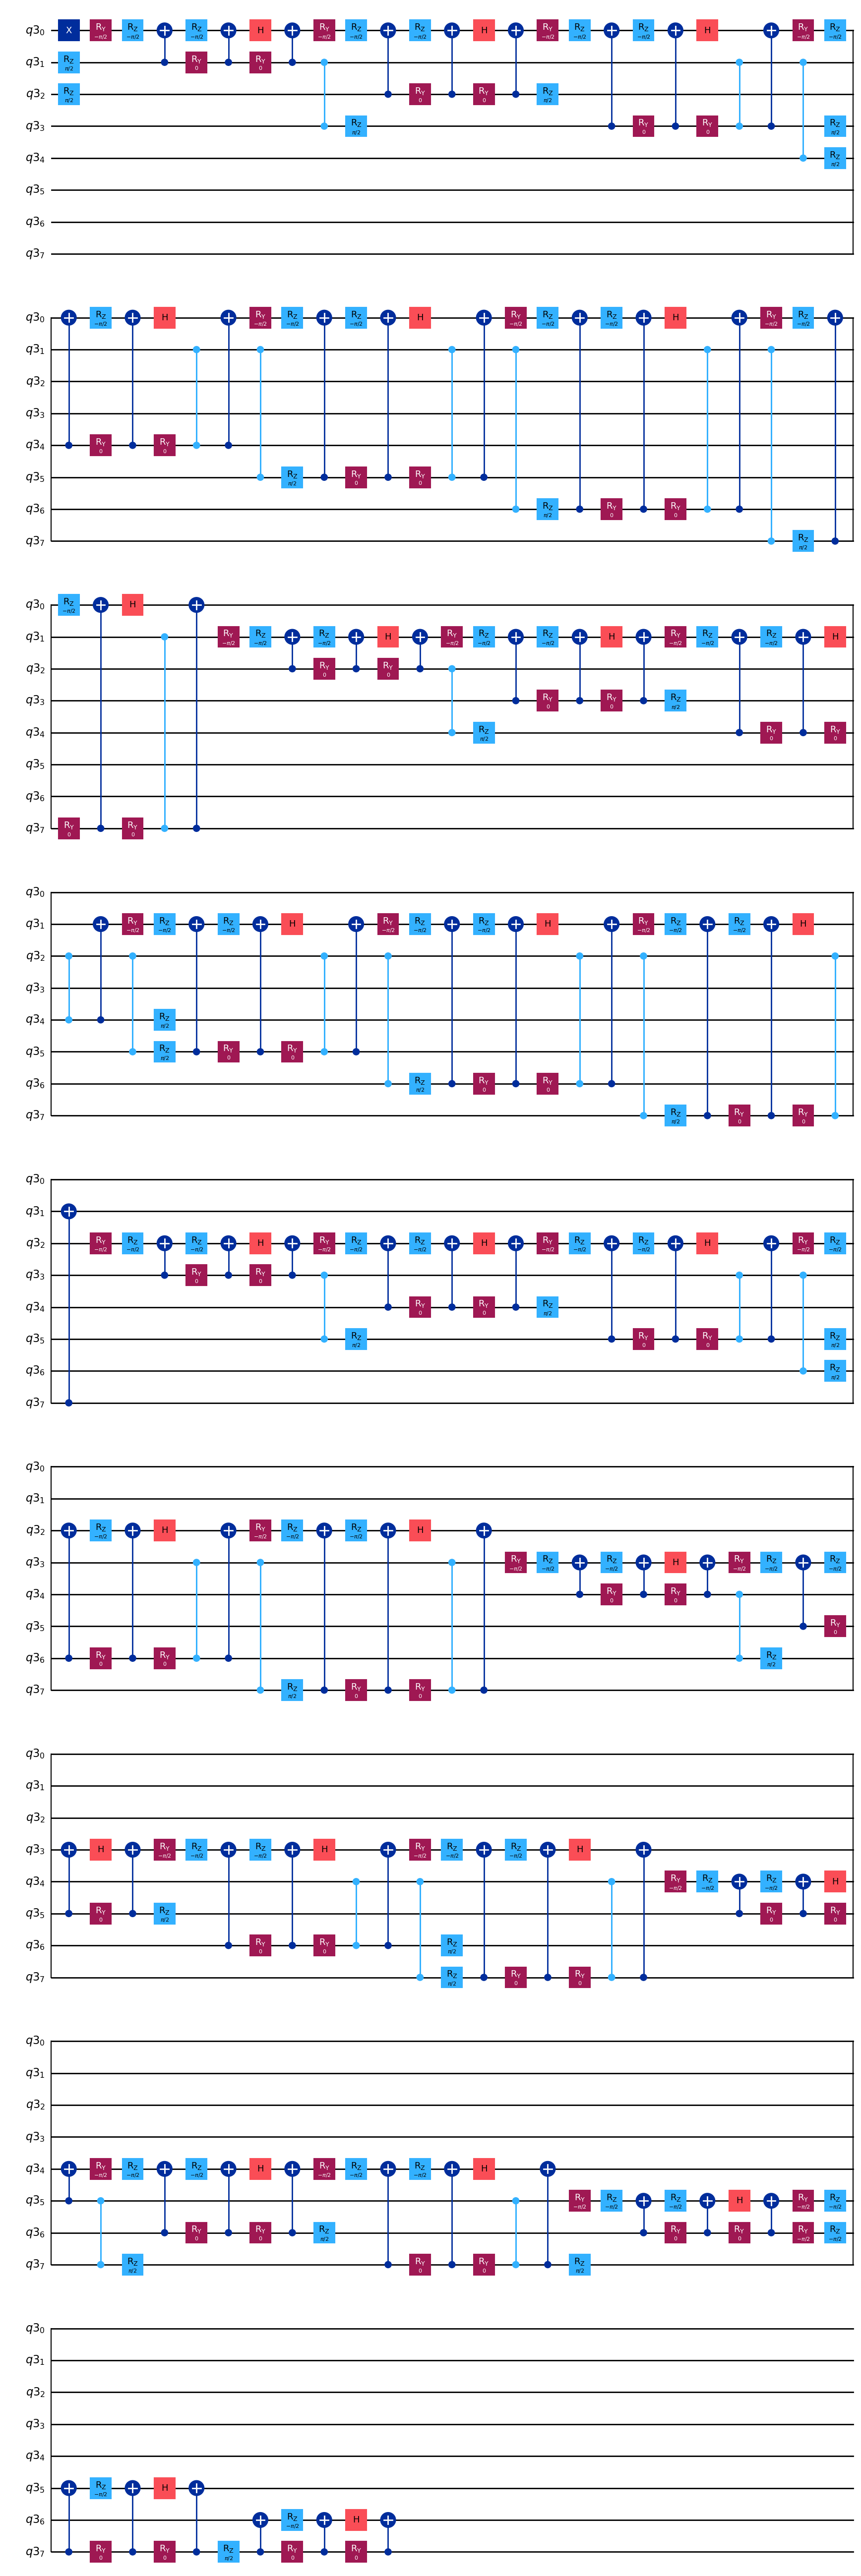

In [22]:
qc.draw('mpl')

In [46]:
def se_yordanov_no_ladder(theta, i, k, qc):
    '''
    this is a function for single fermionic excitation but without the ladder part
    Ansatz is described in the paper 
    PHYSICAL REVIEW A 102, 062612 (2020)
    Efficient quantum circuits for quantum computational chemistry
    Yordan S. Yordanov, David R. M. Arvidsson-Shukur, and Crispin H. W. Barnes

    I call it cluster Ansatz by Yordanov. See corresponding Jupyter notebook about this ansatz

    Parameters:
    theta, float - rotation angle, defines how much of state i is transformed to k, full transition is when theta = pi
    i,k, int - states between which transoition happens
    qc, QuantumCircuit - quantum circuit to which the ry_c set of gates will be added
    '''
    #if k - 1 > i + 1: 
    #    for i_q in range(k - 1, i + 1, -1):
    #        qc.cx(i_q, i_q - 1)
    #qc.cx(k, i)
    if  k - 1 > i + 1: 
        qc.cz(i + 1, k)
    ry_c(theta, i, k, qc)
    if k - 1 > i + 1: 
        qc.cz(i + 1, k)
    qc.cx(k, i)
    #if k - 1 > i + 1: 
    #    for i_q in range(i + 1, k - 1):
    #        qc.cx(i_q + 1, i_q)
    
    return qc

In [49]:
qc_2 = qiskit.QuantumCircuit(6)
theta = np.pi/4
i = 0
k = 5
qc_2 = se_yordanov_no_ladder(theta, i, k, qc_2)

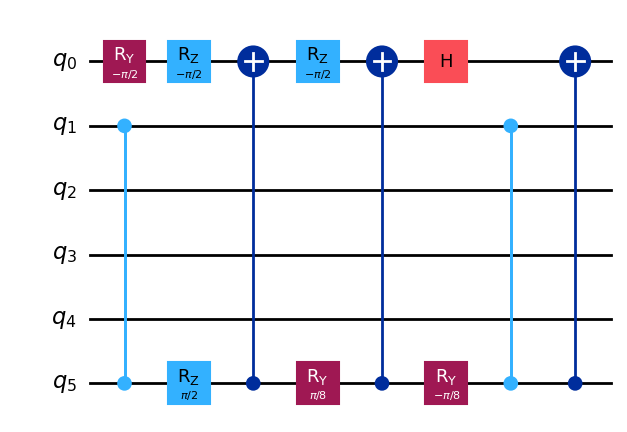

In [50]:
qc_2.draw('mpl')

In [51]:
qc_1 = qiskit.QuantumCircuit(6)
theta = np.pi/4
i = 0
k = 5
qc_1 = vqe_funcs.se_yordanov(theta, i, k, qc_1)

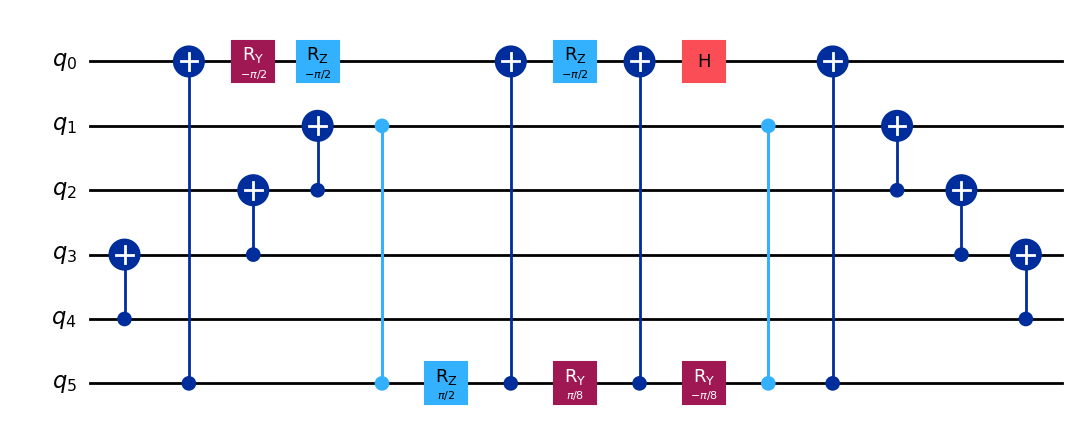

In [52]:
qc_1.draw('mpl')

In [54]:
from qiskit.visualization import circuit_drawer
# Draw the circuit using the matplotlib backend
fig = circuit_drawer(qc_1, output='mpl', style={'fontsize': 16}, fold=51)

# Add a text annotation to the figure
#fig.text(0.5, 0.90, "(a)", ha='center', fontsize=14)

# Save or show
fig.savefig("Yordanov_1.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()

# Draw the circuit using the matplotlib backend
fig_mer = circuit_drawer(qc_2, output='mpl')

# Add a text annotation to the figure
#fig_mer.text(0.5, 0.90, "(b)", ha='center', fontsize=14)

# Save or show
fig_mer.savefig("Yordanov_2.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()